In [135]:
'''
This example shows how to generate the 3-center integrals and the 2-center
integral metric for the density-fitting method.
'''

import scipy
from pyscf import gto, df, lib

mol = gto.Mole()
mol.atom = '''
  C   0.    0.    0.
  O   0.    0.    1.3
'''
mol.basis = 'ccpvdz'
mol.build()
mf = dft.RKS(mol)
mf.chkfile=False
mf.xc = 'pbe'
#mf.max_cycle = 1000
mf.kernel()

dm1 = mf.make_rdm1()
print('dfensity matris', dm1.shape)

# Define the auxiliary fitting basis for 3-center integrals. Use the function
# make_auxmol to construct the auxiliary Mole object (auxmol) which will be
# used to generate integrals.
auxbasis = 'augccpvdz-jk-fit'
auxmol = df.addons.make_auxmol(mol, auxbasis)

# ints_3c is the 3-center integral tensor (ij|P), where i and j are the
# indices of AO basis and P is the auxiliary basis
ints_3c2e = df.incore.aux_e2(mol, auxmol, intor='int3c2e')
ints_2c2e = auxmol.intor('int2c2e')

nao = mol.nao
naux = auxmol.nao

# Compute the DF coefficients (df_coef) and the DF 2-electron (df_eri)
df_coef = scipy.linalg.solve(ints_2c2e, ints_3c2e.reshape(nao*nao, naux).T)
df_coef = df_coef.reshape(naux, nao, nao)

df_eri = lib.einsum('ijP,Pkl->ijkl', ints_3c2e, df_coef)

# Now check the error of DF integrals wrt the normal ERIs
print(abs(mol.intor('int2e') - df_eri).max())


converged SCF energy = -113.159947523474
dfensity matris (28, 28)
0.02626618895552557


In [136]:
print('df coef shape', df_coef.shape)
print('dm shape', dm1.shape)
df_basis = lib.einsum('Pij,ij->P', df_coef, dm1)
print('df_basis', df_basis)
print(len(df_basis))

df coef shape (172, 28, 28)
dm shape (28, 28)
df_basis [ 1.46347044e-01  3.33873047e-01  1.18570548e+00  1.80609078e+00
  2.25799275e+00  5.95358570e-01 -2.52516184e-01  4.19892667e-01
  3.80483656e-01  4.47820934e-02  3.51514078e-04  2.02851454e-17
  7.26576761e-18  2.55523351e-03  7.46585932e-16  1.17864102e-16
  7.04494403e-03  1.08934264e-15  1.93697834e-16  2.45718002e-02
  3.58630309e-16  2.68049613e-17 -1.57376048e-02 -4.27820162e-15
 -7.01811220e-16 -4.42981780e-02 -4.15209297e-15 -5.46977755e-16
 -1.23769951e-02 -2.25009569e-16 -3.81105507e-17  9.02844153e-04
  8.98986292e-18  1.77390824e-18  7.99245764e-04  8.60817688e-18
  9.21813524e-17  7.92465621e-03  4.84326640e-16  1.29205358e-16
  6.85422440e-17  2.62935408e-16  2.20528389e-02  1.42102033e-15
  4.29450552e-16  5.40275683e-17  5.20181747e-16  5.03352473e-02
  2.92121830e-15  6.47251650e-16  5.62262367e-17  2.60513947e-16
  1.11907735e-02  1.56440913e-15  2.76860418e-16  1.38365725e-17
  3.01570734e-18  8.93324599e-04  7

In [142]:
from pyscf.dft import numint
from equiv_dens.utils import grids
from equiv_dens.utils import base as utils
from pyscf import dft
import numpy as np

grid_size = 100

mol = gto.Mole()
mol.atom = '''
  C   0.    0.    0.
  O   1.3    0.    0.
'''
mol.basis = auxbasis 
mol.build()

atoms = {}
atoms['positions'] = mol.atom_coords(unit='Angstrom')[None, :]
atoms['atom_types'] = np.array(mol.elements)
print('positions shape', atoms['positions'].shape)
coords, sample_volume = grids.cubical_grid(atoms, nx=grid_size, ny=grid_size, nz=grid_size, extent=[10, 10, 10], origin=[-4, -4, -4])
ao = numint.eval_ao(mol, coords)
print('ao.shape', ao.shape)
dens = np.einsum('ij,j->i', ao, df_basis)
dens_integral = np.sum(dens * sample_volume)
print('dens.shape', dens.shape)
print('dens_integral', dens_integral/utils.to_bohr**3)

positions shape (1, 2, 3)
mol_dict [('C', array([0., 0., 0.])), ('O', array([1.3, 0. , 0. ]))]
ao.shape (1000000, 172)
dens.shape (1000000,)
dens_integral 13.578178317598555


In [138]:
mol = gto.Mole()
mol.atom = '''
  C   0.    0.    0.
  O   1.3    0.    0.
'''
mol.basis = 'ccpvdz'
mol.build()
mf = dft.RKS(mol)
mf.chkfile=False
mf.xc = 'pbe'
#mf.max_cycle = 1000
mf.kernel()
print('mol atom coords', mol.atom_coords())

ao = numint.eval_ao(mol, coords)
rho = numint.eval_rho2(mol, ao, mf.mo_coeff, mf.mo_occ)
rho_integral = np.sum(rho * sample_volume)
print('rho.shape', rho.shape)
print('rho_integral', rho_integral/utils.to_bohr**3)

converged SCF energy = -113.159947523474
mol atom coords [[0.         0.         0.        ]
 [2.45664396 0.         0.        ]]
rho.shape (1000000,)
rho_integral 13.560017599750788


idx [    50  10050  20050 ... 979950 989950 999950]
coords space shape (1000000, 3)


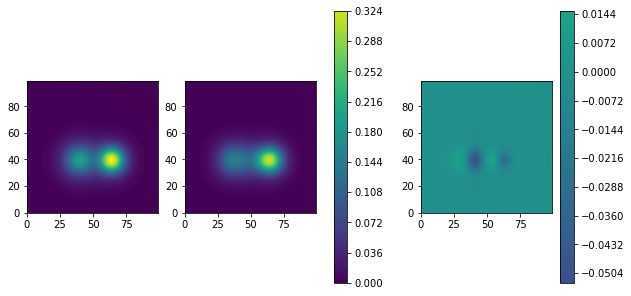

density error 0.012881774134609319


In [139]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
x, y  = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + int(grid_size / 2)
idx = np.ravel_multi_index((x_f, y_f, z_f), (grid_size, grid_size, grid_size))
                
#X, Y, Z = np.meshgrid(np.arange(grid_size) + 38, np.arange(grid_size) + 38, np.arange(grid_size) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(grid_size, grid_size)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = coords 
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

p_dens = rho 
p_dens = p_dens[idx].reshape(grid_size, grid_size)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_pred_dens.pdf', dpi=300)
plt.show()
print('density error', np.sum(np.abs(dens-rho) * sample_volume/utils.to_bohr**3)/dens_integral)